# ARC-AGI-2 custom tensor playground

This notebook is a manual modeling sandbox. Pick any public ARC task, inspect any input/output grid, represent it as an `H × W × 10` tensor, apply your own operations, render the result, and score your submitted tensor against the known target.

ARC itself stores a grid as a 2D matrix of integers `0..9`. Here we encode that losslessly as 10 one-hot channels:

`grid[y, x] = c  <=>  tensor[y, x, c] = 1`

Your custom operation does **not** have to preserve one-hot values. It may return probabilities, logits, or arbitrary real channel scores; evaluation decodes with `argmax(axis=-1)`.

## 0. One-time setup

From the repository root:

```bash
make setup
make data
```

The notebook uses the official public ARC-AGI-2 task repository cloned into `data/ARC-AGI-2`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from arc_agi2_fun.data import load_official_split
from arc_agi2_fun.tensors import (
    NUM_COLORS,
    evaluate_tensor,
    get_task_grid,
    grid_to_tensor,
    tensor_to_grid,
)
from arc_agi2_fun.visualize import plot_grid, plot_task

DATA_DIR = ROOT / 'data' / 'ARC-AGI-2'
print('repo:', ROOT)
print('data:', DATA_DIR)

repo: /home/logankelsch/logxco/competitions/ARC-AGI-2_For_Fun
data: /home/logankelsch/logxco/competitions/ARC-AGI-2_For_Fun/data/ARC-AGI-2


## 1. Load a split and choose any task

Use `training` while developing your approach. Treat `evaluation` as an outer holdout when you want a more honest measurement.

1000 tasks loaded from training
first 20 ids: ['00576224', '007bbfb7', '009d5c81', '00d62c1b', '00dbd492', '017c7c7b', '025d127b', '03560426', '045e512c', '0520fde7', '05269061', '05a7bcf2', '05f2a901', '0607ce86', '0692e18c', '06df4c85', '070dd51e', '08ed6ac7', '09629e4f', '0962bcdd']
selected: 009d5c81
train examples: 5
test examples: 1


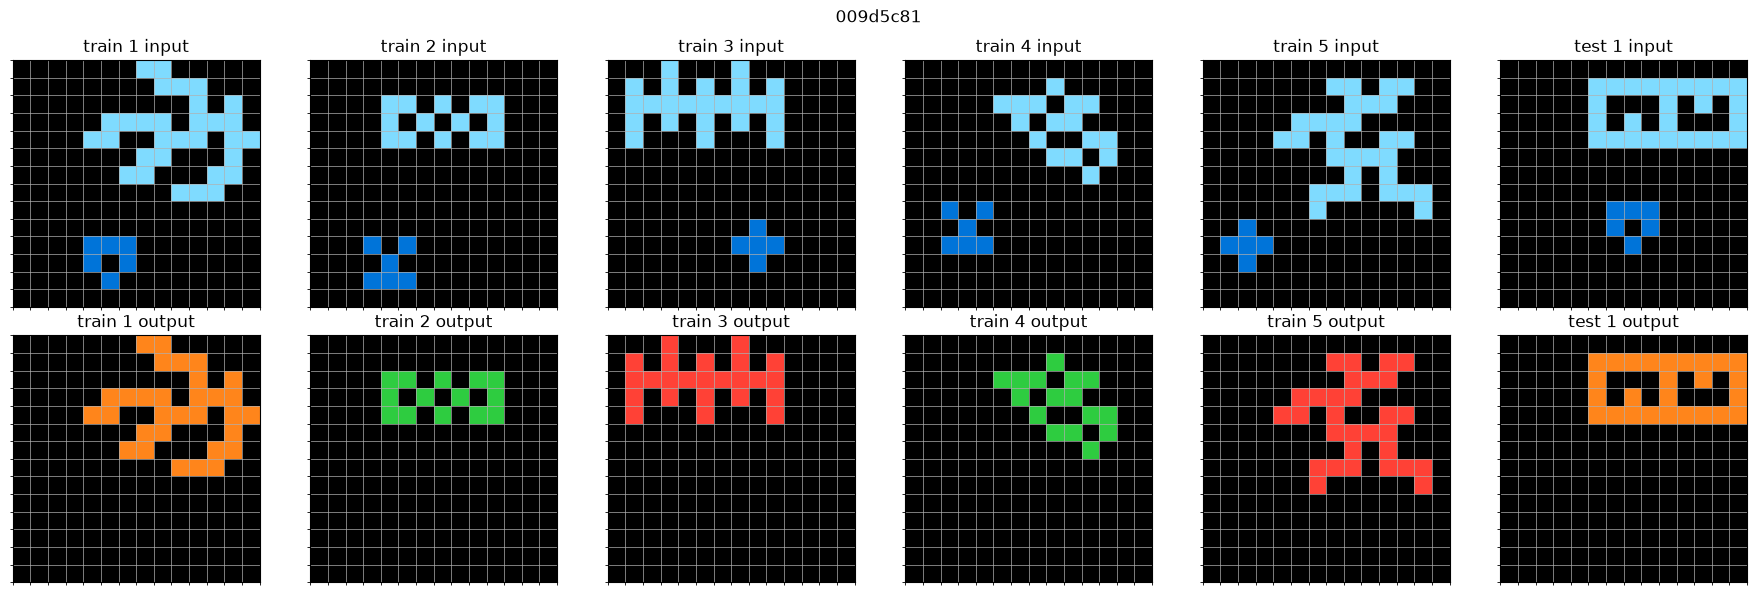

In [2]:
SPLIT = 'training'  # 'training' or 'evaluation'

tasks = load_official_split(DATA_DIR, SPLIT)
task_ids = list(tasks)
print(f'{len(task_ids)} tasks loaded from {SPLIT}')
print('first 20 ids:', task_ids[:20])

TASK_ID = task_ids[2]  # replace with any id printed above
task = tasks[TASK_ID]
print('selected:', TASK_ID)
print('train examples:', len(task.train))
print('test examples:', len(task.test_inputs))

plot_task(task)
plt.show()

In [3]:
from ops.grid_ops import grid_dissection

d = grid_dissection(task.train[0].input)

1
1
1
1
1
1
1
1


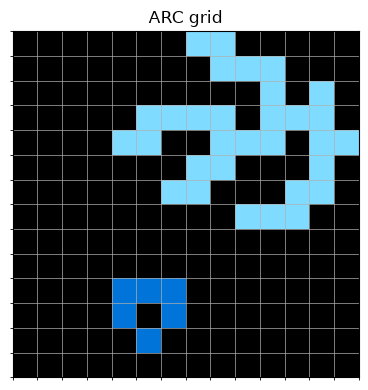

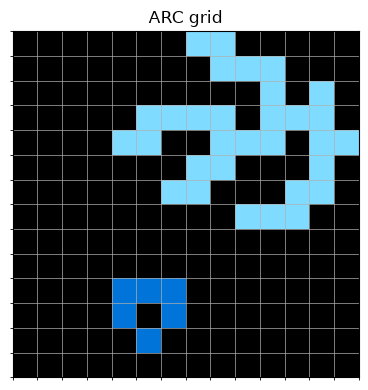

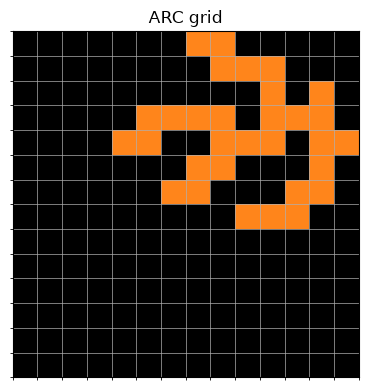

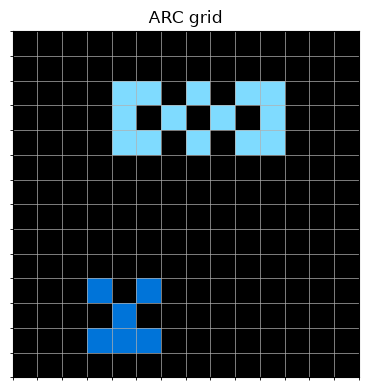

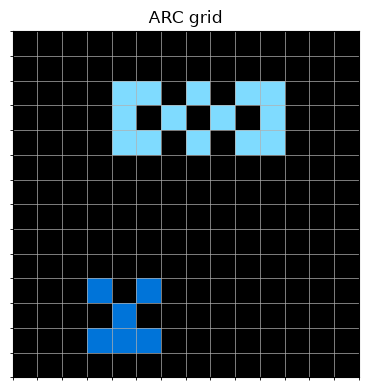

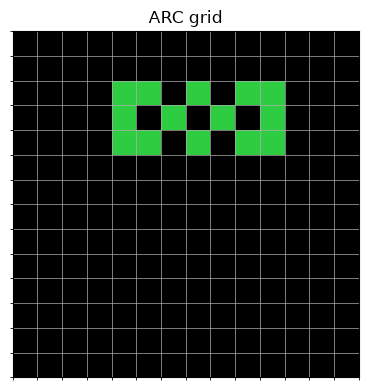

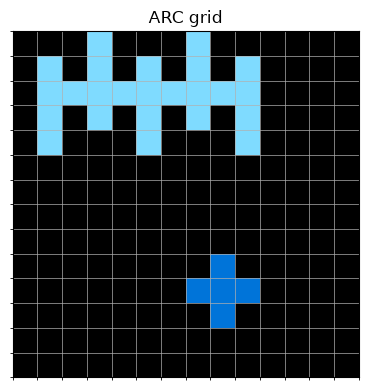

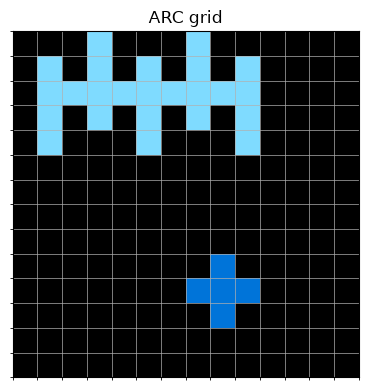

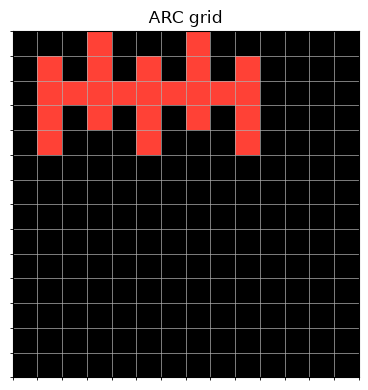

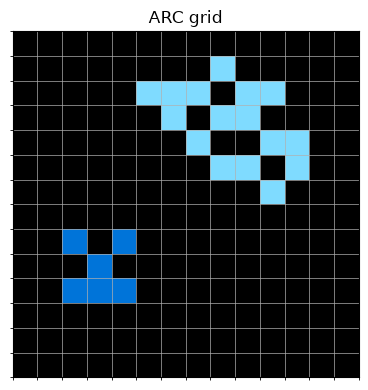

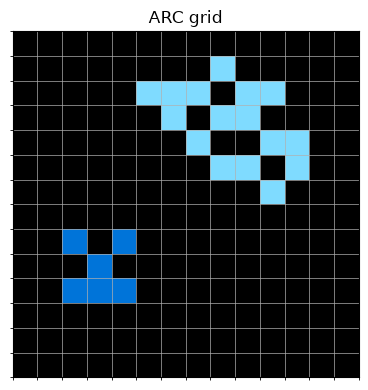

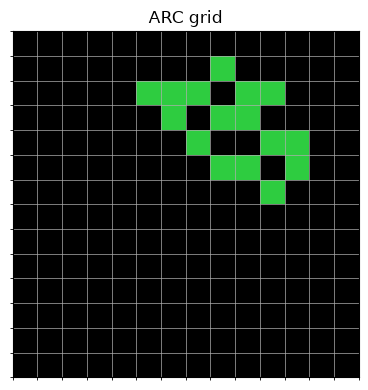

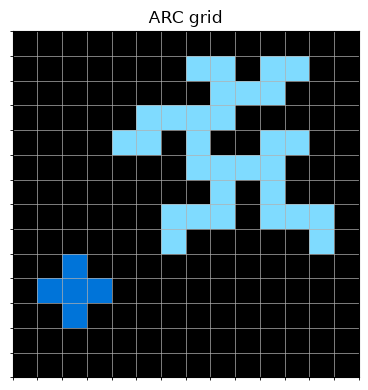

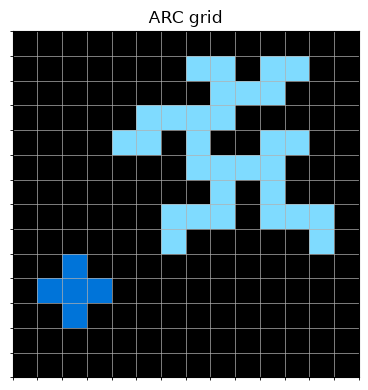

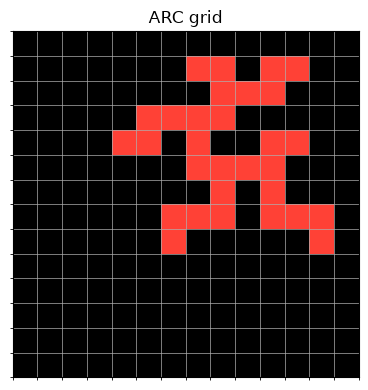

In [89]:
from importlib import reload

import ops.eval as eval
reload(eval)

gpmat = eval.init_gp_mat(task.train)

#print(type(gpmat.data[0]))
#print((gpmat.data[0]))
for i in range(len(task.train)):
    plot_grid(gpmat.input[i])
    plot_grid(gpmat.data[i][0])
    plot_grid(gpmat.output[i])
    print(len(gpmat.data[i]))
print(len(gpmat.op))
print(len(gpmat.source))
print(len(gpmat.status))


<Axes: title={'center': 'ARC grid'}>

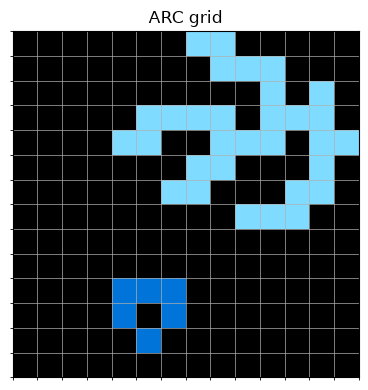

In [37]:
from ops.grid_ops import reconstruct_grid

grid1 = reconstruct_grid(d)

plot_grid(task.train[0].input)

In [1]:
plot_grid(task.train[0].output)

NameError: name 'plot_grid' is not defined

## 2. Render the entire task

Top row shows inputs; bottom row shows the matching outputs when known. Public ARC-AGI-2 files include outputs so you can use them for research/evaluation.

## 3. Pick one example and inspect either the before or after grid

`SECTION='train'` selects a demonstration pair. `SECTION='test'` selects a public test pair. `SIDE='input'` is the before grid and `SIDE='output'` is the after/solution grid.

2D grid shape: (14, 14)
3D tensor shape: (14, 14, 10)
channels: 10


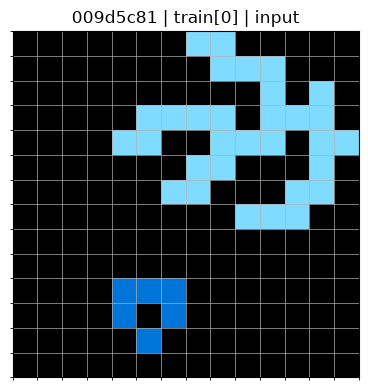

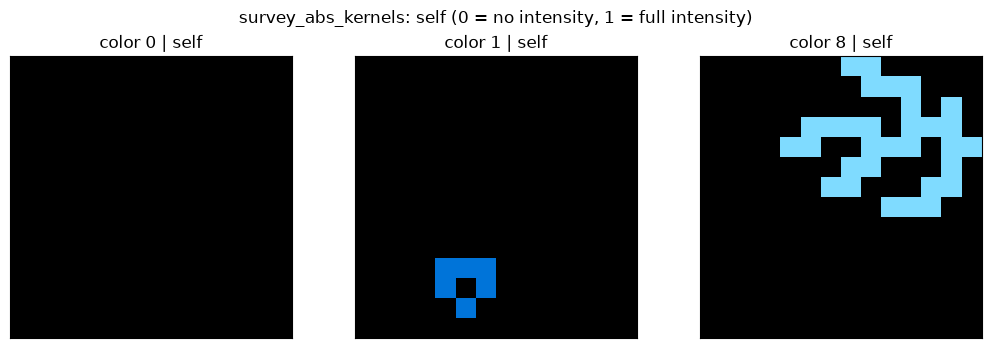

2D grid shape: (14, 14)
3D tensor shape: (14, 14, 10)
channels: 10


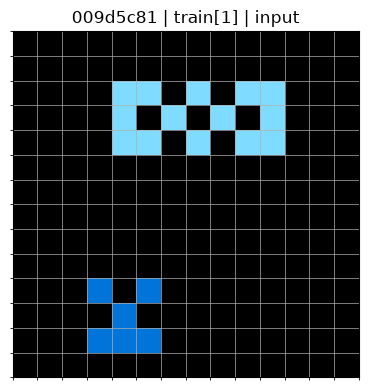

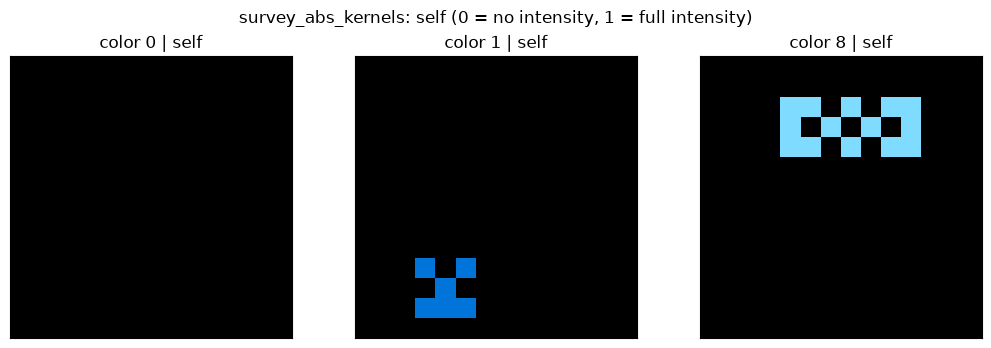

2D grid shape: (14, 14)
3D tensor shape: (14, 14, 10)
channels: 10


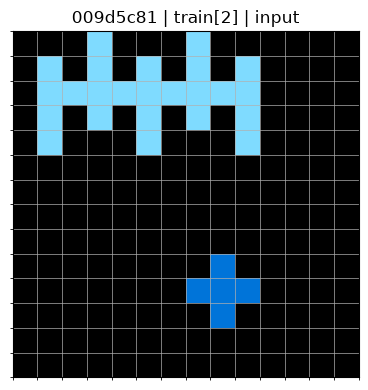

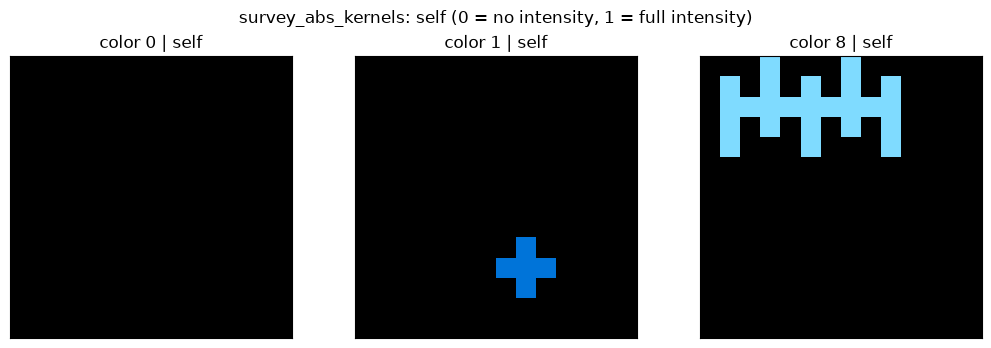

2D grid shape: (14, 14)
3D tensor shape: (14, 14, 10)
channels: 10


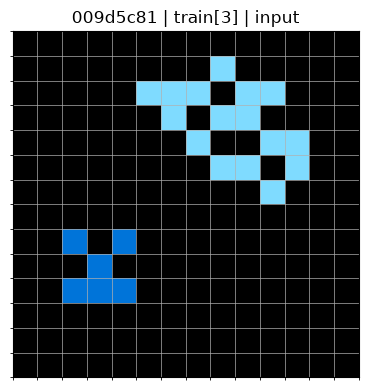

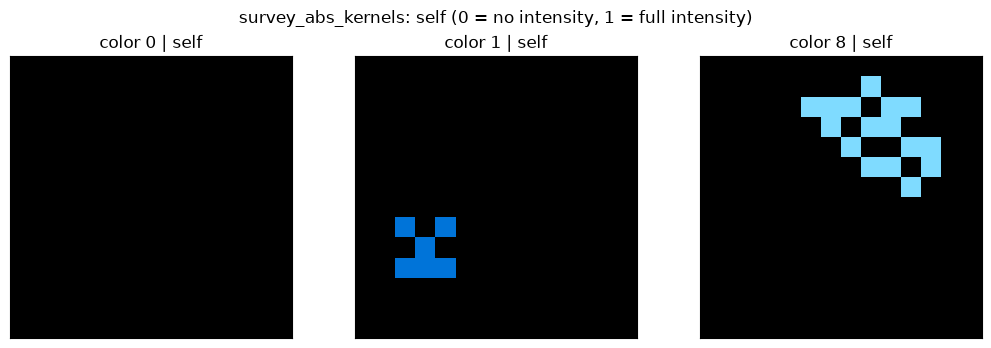

2D grid shape: (14, 14)
3D tensor shape: (14, 14, 10)
channels: 10


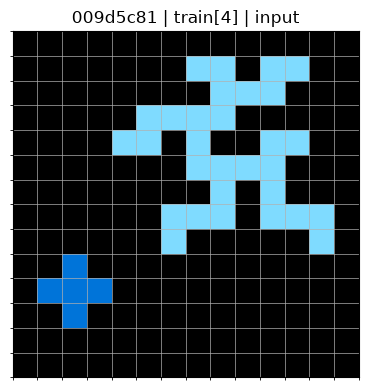

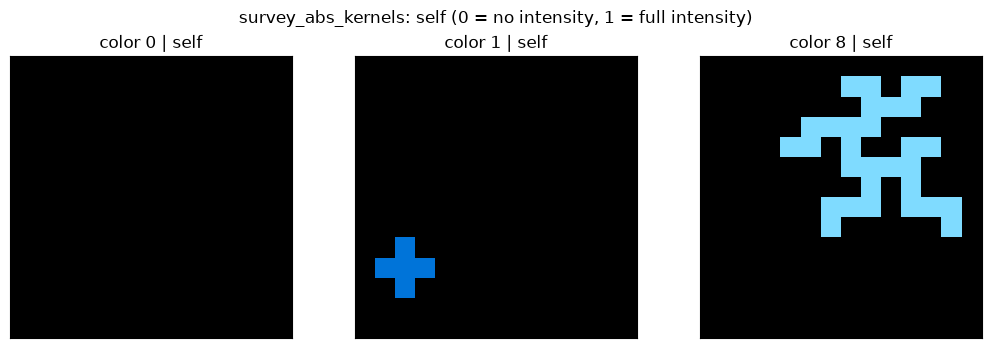

In [30]:
SECTION = 'train'   # 'train' or 'test'
for i in range(5):
    EXAMPLE_INDEX = i
    SIDE = 'input'        # 'input' or 'output'

    selected_grid = get_task_grid(
        task,
        section=SECTION,
        index=EXAMPLE_INDEX,
        side=SIDE,
    )
    selected_tensor = grid_to_tensor(selected_grid)

    print('2D grid shape:', np.asarray(selected_grid).shape)
    print('3D tensor shape:', selected_tensor.shape)
    print('channels:', NUM_COLORS)

    plot_grid(selected_grid, f'{TASK_ID} | {SECTION}[{EXAMPLE_INDEX}] | {SIDE}')
    plt.show()

    import numpy as np
    from ops.alpha_ops import survey_abs_kernels

    # selected_grid is your normal H x W ARC integer grid
    x = np.asarray(selected_grid, dtype=float)

    responses = survey_abs_kernels(
        x,
        kernel="self",
        plot=True,
    )

    # Example: inspect one raw response matrix
    #responses

## 4. Inspect the actual 3D representation

For every `(y, x)` cell, the length-10 vector identifies its color. A color-3 pixel is `[0,0,0,1,0,0,0,0,0,0]`.

In [29]:
Y = 0
X = 0

print('integer color:', selected_grid[Y][X])
print('channel vector:', selected_tensor[Y, X])
print('active channel:', int(np.argmax(selected_tensor[Y, X])))

selected_tensor

integer color: 0
channel vector: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
active channel: 0


array([[[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0.

## 5. Build a modeling pair

For actual transformation work, use the input tensor as `model_input` and the corresponding output tensor as `target_tensor`.

In [30]:
PAIR_SECTION = 'train'  # switch to 'test' for public held-out examples
PAIR_INDEX = 0

input_grid = get_task_grid(task, section=PAIR_SECTION, index=PAIR_INDEX, side='input')
target_grid = get_task_grid(task, section=PAIR_SECTION, index=PAIR_INDEX, side='output')

model_input = grid_to_tensor(input_grid)
target_tensor = grid_to_tensor(target_grid)

print('input tensor:', model_input.shape)
print('target tensor:', target_tensor.shape)

input tensor: (14, 14, 10)
target tensor: (14, 14, 10)


## 6. Your custom operation sandbox

Edit **only this function** while experimenting. Input is an `H × W × 10` NumPy array. Output must also be a 3D array with 10 channels, although height and width may change when the inferred ARC rule changes output dimensions.

Useful spatial operations preserve the channel axis:

```python
np.rot90(x, 1, axes=(0, 1))
x[:, ::-1, :]       # horizontal flip
x[::-1, :, :]       # vertical flip
```

You can also manipulate channels, build masks, detect objects, create a brand-new tensor, or eventually call a learned model.

In [31]:
def my_operation(x: np.ndarray) -> np.ndarray:
    # ---- YOUR MODEL / TRANSFORMATION GOES HERE ----
    y = x.copy()

    # Examples to try one at a time:
    # y = np.rot90(x, 1, axes=(0, 1))
    # y = x[:, ::-1, :]
    # y = x[::-1, :, :]

    return y

submitted_tensor = my_operation(model_input.copy())
print('submitted tensor shape:', submitted_tensor.shape)

submitted tensor shape: (14, 14, 10)


## 7. Render your submitted 3D tensor

Rendering first decodes the 10 channels by `argmax`, exactly like the evaluator.

In [ ]:
submitted_grid = tensor_to_grid(submitted_tensor)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
plot_grid(input_grid, 'input', ax=axes[0])
plot_grid(submitted_grid, 'your submitted output', ax=axes[1])
plot_grid(target_grid, 'true output', ax=axes[2])
plt.show()

## 8. Evaluate the submitted tensor against the solution

Competition success is **exact decoded-grid equality**, including output dimensions. Cell accuracy is provided only as a useful diagnostic while building your model.

In [ ]:
evaluation = evaluate_tensor(submitted_tensor, target_tensor)
pd.DataFrame([evaluation.to_dict()])

## 9. Direct matrix experimentation

You do not need to use `my_operation`. Any `H × W × 10` array can be submitted to the evaluator. For example, this is useful if a neural model returns logits.

In [ ]:
# Example placeholder for arbitrary model scores/logits.
# Replace this with the output of whatever modeling approach you build.
model_scores = submitted_tensor.astype(np.float32)

result = evaluate_tensor(model_scores, target_tensor)
print(result)
print('decoded prediction:')
print(np.asarray(tensor_to_grid(model_scores)))

## 10. Modeling contract

This notebook does not impose a modeling philosophy. Your operation can become convolutional, object-based, symbolic, grammatical, genetic, MCTS-driven, or hybrid.

The fixed contract is:

`ARC grid -> H×W×10 tensor -> your operation/model -> H'×W'×10 tensor -> exact evaluation`.

## 11. Alpha operations: absolute neighborhood surveys

The first notebook-local analytical operation lives in `ops/alpha_ops.py`. `survey_abs_kernels` compares every pixel/vector with selected neighbors using absolute differences. With `kernel='all'`, it evaluates the full default kernel bank and returns a dictionary of raw `H × W` response maps.

In [ ]:
from ops.alpha_ops import DEFAULT_ABS_KERNELS, survey_abs_kernels

print('available alpha kernels:')
for name, kernel in DEFAULT_ABS_KERNELS.items():
    print(f'\n{name}:\n{kernel}')

In [ ]:
# Run the full survey directly on the H × W × 10 ARC tensor.
alpha_responses = survey_abs_kernels(
    model_input,
    kernel='all',
    plot=True,
)

# Raw floating response maps remain available for your own modeling.
alpha_responses['left']

A custom kernel can be supplied directly as a 1D or 2D list/array. For example, `[1, 1, 0]` is the same center-anchored left survey as the named `left` kernel.

In [ ]:
custom_left = survey_abs_kernels(
    model_input,
    kernel=[1, 1, 0],
    plot=True,
)
custom_left